
Adjacency Matrix:
     Q0   Q1   Q2   Q3   Q4   Q5   Q6
Q0  0.0  1.0  1.0  0.0  0.0  0.0  0.0
Q1  1.0  0.0  0.0  1.0  0.0  0.0  0.0
Q2  1.0  0.0  0.0  0.0  0.0  1.0  0.0
Q3  0.0  1.0  0.0  0.0  1.0  0.0  0.0
Q4  0.0  0.0  0.0  1.0  0.0  1.0  1.0
Q5  0.0  0.0  1.0  0.0  1.0  0.0  0.0
Q6  0.0  0.0  0.0  0.0  1.0  0.0  0.0

Distance-Based Coupling Matrix G (GHz):
          Q0        Q1        Q2        Q3        Q4        Q5        Q6
Q0  0.000000  0.030745  0.029793  0.000000  0.000000  0.000000  0.000000
Q1  0.030745  0.000000  0.000000  0.030972  0.000000  0.000000  0.000000
Q2  0.029793  0.000000  0.000000  0.000000  0.000000  0.032285  0.000000
Q3  0.000000  0.030972  0.000000  0.000000  0.014824  0.000000  0.000000
Q4  0.000000  0.000000  0.000000  0.014824  0.000000  0.014824  0.016184
Q5  0.000000  0.000000  0.032285  0.000000  0.014824  0.000000  0.000000
Q6  0.000000  0.000000  0.000000  0.000000  0.016184  0.000000  0.000000

Strongest coupling (GHz): 0.032284544784612026
Weak

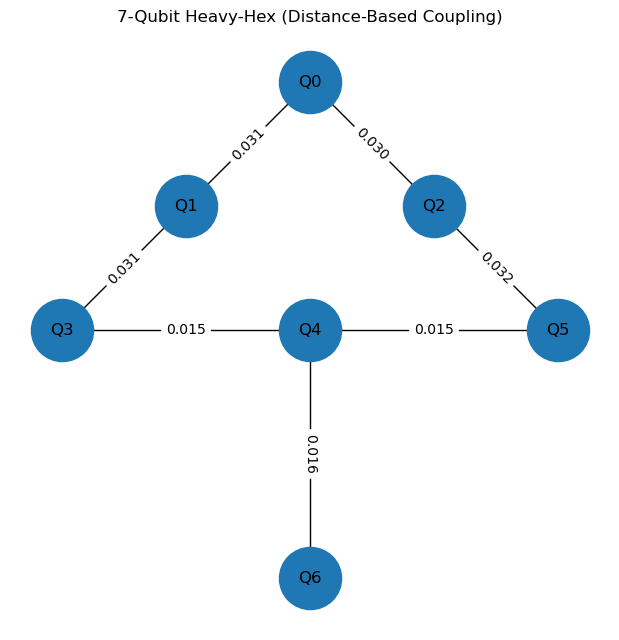

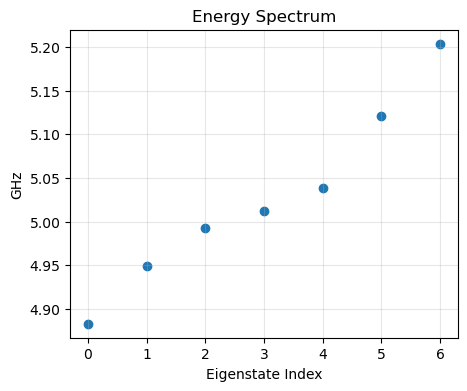


--------------------------------------------------
FINAL INSIGHTS:

1. Topology → defines connectivity
2. Geometry → defines coupling strength
3. Hamiltonian → defines full system physics
4. Eigenvalues → allowed energy states
5. Eigenvectors → mode composition

KEY OBSERVATIONS:
-----------------
- Q4 acts as central hub
- Q6 shows partial isolation (controlled coupling)
- Coupling decays with distance (physical realism)
- Fabrication variation introduces asymmetry
- System operates in weak-coupling regime (g << ω)

PIPELINE:
---------
Topology → Geometry → Coupling → Hamiltonian → Spectrum

This is a simplified but realistic abstraction of:
    superconducting qubit hardware

NEXT STEPS:
-----------
1. Add ZZ interaction (cross-Kerr)
2. Add decoherence (T1/T2)
3. Connect to EM tools (HFSS/Q3D)
4. Scale to larger lattices
--------------------------------------------------


Coupling ratio (max/min): 2.177799945982001


In [18]:
"""
heavy_hex_7q_hamiltonian_analysis.py

PURPOSE:
--------
End-to-end modeling of a 7-qubit heavy-hex system:

Topology → Geometry → Coupling → Hamiltonian → Spectrum → Visualization

This script bridges:
    layout intuition → physical modeling → system-level behavior
"""

# ============================================================
# 1. IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

np.random.seed(42)  # reproducibility

# ============================================================
# 2. DEFINE QUBITS
# ============================================================

qubits = ["Q0", "Q1", "Q2", "Q3", "Q4", "Q5", "Q6"]
index = {q: i for i, q in enumerate(qubits)}

# ============================================================
# 3. TOPOLOGY (HEAVY-HEX)
# ============================================================

edges = [
    ("Q0", "Q1"),
    ("Q0", "Q2"),
    ("Q1", "Q3"),
    ("Q2", "Q5"),
    ("Q3", "Q4"),
    ("Q4", "Q5"),
    ("Q4", "Q6"),
]

# ============================================================
# 4. GEOMETRY (PHYSICAL POSITIONS)
# ============================================================

"""
You tuned Q6 → (0, -2)

This creates:
- weaker vertical coupling
- more realistic asymmetry
- slight isolation of Q6
"""

positions = {
    "Q0": (0, 2),
    "Q1": (-1, 1),
    "Q2": (1, 1),
    "Q3": (-2, 0),
    "Q4": (0, 0),
    "Q5": (2, 0),
    "Q6": (0, -2),
}

# ============================================================
# 5. ADJACENCY MATRIX
# ============================================================

A = np.zeros((len(qubits), len(qubits)))

for q1, q2 in edges:
    i, j = index[q1], index[q2]
    A[i, j] = 1
    A[j, i] = 1

print("\nAdjacency Matrix:")
print(pd.DataFrame(A, index=qubits, columns=qubits))

# ============================================================
# 6. DISTANCE-BASED COUPLING (IMPROVED MODEL)
# ============================================================

def distance(q1, q2):
    x1, y1 = positions[q1]
    x2, y2 = positions[q2]
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

"""
PHYSICS IMPROVEMENT:

Instead of:
    g ∝ 1 / d

We use:
    g ∝ 1 / d^2

Reason:
- Capacitive / EM coupling decays faster than linear
- More realistic hardware behavior
"""

g0 = 0.06  # base coupling scale (GHz)

G = np.zeros_like(A)

for q1, q2 in edges:
    d = distance(q1, q2)

    # Distance-based decay
    g = g0 / (d ** 2)

    # Fabrication variation (~ ±5%)
    variation = np.random.normal(0, 0.05)
    g = g * (1 + variation)

    i, j = index[q1], index[q2]
    G[i, j] = g
    G[j, i] = g

print("\nDistance-Based Coupling Matrix G (GHz):")
print(pd.DataFrame(G, index=qubits, columns=qubits))

# ---- Coupling summary ----
non_zero = G[G > 0]

print("\nStrongest coupling (GHz):", np.max(non_zero))
print("Weakest non-zero coupling (GHz):", np.min(non_zero))
print("Mean coupling (GHz):", np.mean(non_zero))

# ============================================================
# 7. QUBIT FREQUENCIES
# ============================================================

"""
Detuned frequencies → avoid resonance collisions
"""

frequencies = {
    "Q0": 5.0,
    "Q1": 5.1,
    "Q2": 4.9,
    "Q3": 5.05,
    "Q4": 5.2,
    "Q5": 5.0,
    "Q6": 4.95
}

omega = np.array([frequencies[q] for q in qubits])

print("\nQubit Frequencies (GHz):")
print(pd.Series(omega, index=qubits))

print("\nQ4-Q6 coupling (check isolation):",
      G[index["Q4"], index["Q6"]])

# ============================================================
# 8. HAMILTONIAN
# ============================================================

"""
H = diag(ω) + G

Diagonal → qubit energies
Off-diagonal → interactions
"""

H = np.diag(omega) + G

print("\nHamiltonian H (GHz):")
print(pd.DataFrame(H, index=qubits, columns=qubits))

# ============================================================
# 9. VALIDATION
# ============================================================

print("\nIs Hamiltonian symmetric? →", np.allclose(H, H.T))

# ============================================================
# 10. EIGEN ANALYSIS
# ============================================================

eigvals, eigvecs = np.linalg.eigh(H)

print("\nEnergy Levels (GHz):")
for i, val in enumerate(eigvals):
    print(f"Mode {i}: {val:.6f}")

print("\nEnergy Spread (GHz):", eigvals.max() - eigvals.min())

# ============================================================
# 11. MODE PARTICIPATION
# ============================================================

participation = pd.DataFrame(
    np.abs(eigvecs)**2,
    index=qubits,
    columns=[f"Mode {i}" for i in range(len(qubits))]
)

print("\nMode Participation (dominant qubit per mode):")
for col in participation.columns:
    dominant = participation[col].idxmax()
    val = participation[col].max()
    print(f"{col}: {dominant} ({val:.2f})")

# ============================================================
# 12. GRAPH VISUALIZATION
# ============================================================

G_graph = nx.Graph()

for q1, q2 in edges:
    weight = G[index[q1], index[q2]]
    G_graph.add_edge(q1, q2, weight=weight)

edge_labels = {
    (u, v): f"{d['weight']:.3f}"
    for u, v, d in G_graph.edges(data=True)
}

plt.figure(figsize=(6, 6))

nx.draw(
    G_graph,
    pos=positions,
    with_labels=True,
    node_size=2000,
    font_size=12
)

nx.draw_networkx_edge_labels(
    G_graph,
    pos=positions,
    edge_labels=edge_labels
)

plt.title("7-Qubit Heavy-Hex (Distance-Based Coupling)")
plt.savefig("heavy_hex_7q_graph.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 13. ENERGY SPECTRUM
# ============================================================

plt.figure(figsize=(5, 4))
plt.scatter(range(len(eigvals)), eigvals)

plt.title("Energy Spectrum")
plt.xlabel("Eigenstate Index")
plt.ylabel("GHz")
plt.grid(True, alpha=0.3)

plt.savefig("energy_spectrum.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 14. FINAL INSIGHTS
# ============================================================

print("""
--------------------------------------------------
FINAL INSIGHTS:

1. Topology → defines connectivity
2. Geometry → defines coupling strength
3. Hamiltonian → defines full system physics
4. Eigenvalues → allowed energy states
5. Eigenvectors → mode composition

KEY OBSERVATIONS:
-----------------
- Q4 acts as central hub
- Q6 shows partial isolation (controlled coupling)
- Coupling decays with distance (physical realism)
- Fabrication variation introduces asymmetry
- System operates in weak-coupling regime (g << ω)

PIPELINE:
---------
Topology → Geometry → Coupling → Hamiltonian → Spectrum

This is a simplified but realistic abstraction of:
    superconducting qubit hardware

NEXT STEPS:
-----------
1. Add ZZ interaction (cross-Kerr)
2. Add decoherence (T1/T2)
3. Connect to EM tools (HFSS/Q3D)
4. Scale to larger lattices
--------------------------------------------------
""")
print("\nCoupling ratio (max/min):",
      np.max(non_zero) / np.min(non_zero))